# 1. Do the two quarters in your note match Finance's books?

**Week 1, Friday. The lab debrief, chapter 1 of 3.** This morning each of you took a raw
two-quarter export to a four-part note, alone, in two hours. This chapter replays the step most
rooms dropped when the clock ran: the check that the data you analysed is still the data Finance
booked.

**Who needs the answer.** Anand Iyer, Kalpa Retail's finance controller, checks the note's first
line against his control totals before any number reaches Meera Raghavan, the CEO, at Monday's
growth review. A first line that points the wrong way sends the review after the wrong question,
and Marketing's Rs 12 crore request to win new customers gets judged against a quarter that did not
happen. Anand returns the note, and the team's next number is read with suspicion.

**The questions on the way.**

1. What headline does a pass that skips the reconciliation send?
2. Which check should run before the number is sent, and what does each one cost?
3. What does the count check fix, and what does it leave behind?
4. Which two moves walk the hurried sum to Finance's total?
5. Does a sum of the decisions themselves land on the same two moves?

**The metric at stake.** Booked revenue per quarter, the rupees of the orders recorded as sales
in that quarter, and its change from Q1 to Q2, which the note leads with. A control total is the
source system's own count of orders and sum of rupees for a period; a clean pass must land on it.

**Who else faces this.** Nykaa, the beauty and fashion retailer, reports two numbers for the same
quarter: gross merchandise value (GMV), the value of everything customers ordered at the prices
charged, before cancellations, returns and tax come out, and revenue from operations, the income the
company books in its own accounts. For April to June 2025 they were Rs 4,182 crore and Rs 2,155
crore (FSN E-Commerce Ventures press release, 12 August 2025), so an analyst there who quotes one
to the owner of the other is out by nearly half, and every internal figure says which it is and
bridges to the books. A public case shows what an unreconciled pipeline hides: in October 2020
Public Health England said 15,841 positive COVID-19 cases from 25 September to 2 October had been
left out of the reported daily figures because files exceeded a size limit (UK government
statement, 4 October 2020). No step raised an error, and the rows were simply missing.

**Before you read on.** This notebook runs on an invented export built for the debrief: 175 rows
over two quarters, with Finance's control totals beside it, carrying the week's four kinds of defect
in places this morning's file does not. Its numbers are labelled invented wherever they appear, and
none of them is Kalpa's or this morning's. After each step an empty cell gives the lines that run
the same step on this morning's lab export. It ships empty so that the notebook shows nobody what the
lab file holds before they have run the lab; type the lines and run the cells in order.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import statistics
from math import comb

QUARTERS = ("Q1", "Q2")
SEGS = ("Retail-Core", "Retail-Plus", "Student", "Business")


def load_export(which):
    """An export and Finance's control totals for it: "invented" for this debrief, "lab" for this morning's file."""
    orders = kit.load_csv(f"C2_W01_D05_{which}_orders_STUDENT.csv")
    book = {c["quarter"]: c for c in kit.load_csv(f"C2_W01_D05_{which}_control_STUDENT.csv")}
    return orders, book


def change(a, b):
    """Percentage change from a to b."""
    return 100 * (b / a - 1)


def ctl(q, book=None):
    """Finance's rupees and orders for a quarter, from the invented export's book unless another is given."""
    book = book or control
    return int(book[q]["amount_rs"]), int(book[q]["orders"])


def read_value(text):
    """The number an amount stored as text holds, read the way a person reads it in the forms this
    week's exports used; None when reading it would take a guess."""
    t = str(text).strip().replace("Rs", "").replace(",", "").replace(" ", "")
    try:
        return round(float(t))
    except ValueError:
        return None


rows, control = load_export("invented")
print(f"The invented export: {len(rows)} rows over two quarters, with Finance's control totals for "
      f"{' and '.join(sorted(control))}. Every number it gives is invented.")

The invented export: 175 rows over two quarters, with Finance's control totals for Q1 and Q2. Every number it gives is invented.


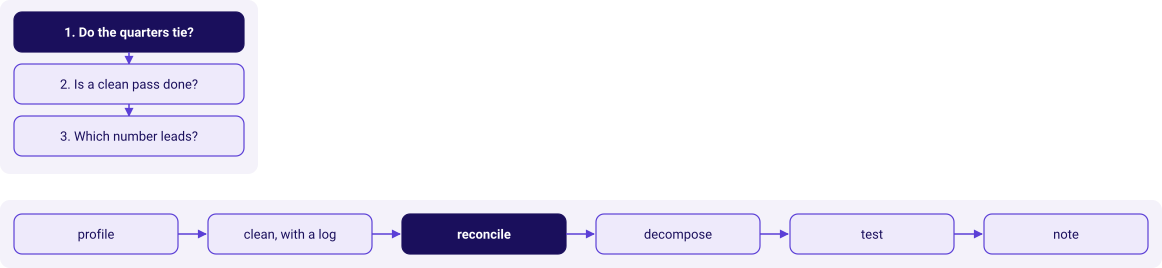

In [2]:
kit.side_by_side(
    kit.ladder(["Do the quarters tie?", "Is a clean pass done?", "Which number leads?"], lit=0, show=False),
    kit.flow(["profile", "clean, with a log", "reconcile", "decompose", "test", "note"], lit=2, show=False),
)

**Two passes, as small functions.** `quarter_totals` sums each quarter of an export, either
reading every value with `read_value` from the first cell or setting any value that will not
convert to zero, the way a hurried pass does; `first_of_each` keeps one row per order id,
Wednesday's identity rule. Both take the export as an argument, so the your-turn cells can hand
them this morning's file.

In [3]:
def quarter_totals(src, text_to_zero):
    """Each quarter's rupees and rows, with unreadable values set to zero or read."""
    out = {}
    for q in QUARTERS:
        s = n = 0
        for r in src:
            if r["quarter"] != q:
                continue
            v = r["amount"]
            s += (int(v) if v.isdigit() else 0) if text_to_zero else read_value(v)
            n += 1
        out[q] = (s, n)
    return out


def first_of_each(src):
    """One row per order id, the first to arrive."""
    kept = {}
    for r in src:
        kept.setdefault(r["order_id"], r)
    return list(kept.values())


truth = change(ctl("Q1")[0], ctl("Q2")[0])
print(f"Invented: Finance's books say Q1 to Q2 {truth:+.1f}%, "
      f"from {kit.rupees(ctl('Q1')[0])} to {kit.rupees(ctl('Q2')[0])}")

Invented: Finance's books say Q1 to Q2 -35.0%, from Rs 40,00,000 to Rs 26,00,000


## 1. What headline does a pass that skips the reconciliation send?

Most notes this morning were built on a pass that kept the rows as they arrived and set any value
that would not convert to zero. It runs to the end without an error, so nothing on the screen says
to stop.

**Predict before you run.** On the invented export, what Q1 to Q2 change does that pass report?

- a) A fall of about a third, the same as Finance's books.
- b) A rise of about a fifth.
- c) A fall of about a sixth.
- d) No change, since both quarters hold about eighty orders.

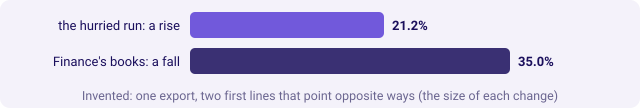

In [4]:
hurried = quarter_totals(rows, text_to_zero=True)
h_change = change(hurried["Q1"][0], hurried["Q2"][0])
kit.stats([(f"{h_change:+.1f}%", "Q1 to Q2, the hurried run", "invented"),
           (f"{truth:+.1f}%", "Q1 to Q2, Finance's books", "invented, from the control file"),
           ("0", "errors raised", "the pass ran to the end")])
kit.bars([("the hurried run: a rise", round(abs(h_change), 1)), ("Finance's books: a fall", round(abs(truth), 1))],
         fmt=lambda v: f"{v:.1f}%", lit=(1,), width=640,
         title="Invented: one export, two first lines that point opposite ways (the size of each change)")

In [5]:
kit.check("the hurried run misses Finance's rupee totals", any(hurried[q][0] != ctl(q)[0] for q in QUARTERS))
kit.check("the hurried run points the opposite way to the books", h_change > 0 > truth,
          f"{h_change:+.1f}% against {truth:+.1f}%")

**What happened.** The answer is b. On the invented export the hurried pass reports Q2 up 21.2
percent, from Rs 31,50,000 on 83 rows to Rs 38,16,420 on 92 rows, and Finance's control file says
the quarter fell 35.0 percent.

**The plausible wrong answer.** "Q2 grew 21.2 percent; the top line needs no action." The
arithmetic is right, the file is Finance's own export, and nothing on the screen looks broken.

**Why it is wrong.** Nobody asked whether the data summed is the data Finance booked. Sent to
Meera, the line tells her that a quarter which fell was a good one, and the review spends its time
on Marketing's plans instead of on the fall. The check that catches it is one comparison with the
control file, in orders and in rupees.

**Your turn, on this morning's file.** Load the lab export and its control totals, run the same
hurried pass on it, and put it beside Finance's totals. Type these lines into the empty cell below
and run it:

```python
lab, lab_book = load_export("lab")
lab_hurried = quarter_totals(lab, text_to_zero=True)
kit.table(["quarter", "rows summed", "Finance's orders", "rupees summed", "Finance's rupees"],
          [(q, lab_hurried[q][1], ctl(q, lab_book)[1], kit.rupees(lab_hurried[q][0]),
            kit.rupees(ctl(q, lab_book)[0])) for q in QUARTERS],
          caption="This morning's hurried run against Finance's control totals")
print(f"hurried headline {change(lab_hurried['Q1'][0], lab_hurried['Q2'][0]):+.1f}%, "
      f"the books {change(ctl('Q1', lab_book)[0], ctl('Q2', lab_book)[0]):+.1f}%")
```

Does this morning's hurried headline point the same way as the books, and does each quarter miss
in orders, in rupees, or both?

## 2. Which check should run before the number is sent, and what does each one cost?

The question at this step is narrow: before any branch of the tree is read, is the data you
cleaned still the data Finance booked? A team has four ways to answer it.

| Option | What it does | What it needs from outside the file |
|---|---|---|
| A. Trust the pass | Sum what the cleaning pass kept and move on to the tree | Nothing |
| B. Count check | Rows read equal rows kept plus rows rejected, and orders per quarter equal Finance's order counts | Finance's order counts |
| C. Counts and rupees, with a bridge | B, plus each quarter's rupees against Finance's control total, and a bridge from what was read to what was kept | Finance's rupee totals too |
| D. Order-level match | Every kept order matched to Finance's ledger, line by line | The ledger itself, which no export here carries |

The cell below sizes the options on what separates them: the analyst's minutes and cells, what
each can see, and how far the headline it lets through sits from the books. The computer's share
of every option is under a millisecond, so the minutes are an analyst's at the lab brief's pace,
and D's is this programme's estimate for a request to Finance and a join. D cannot run on an
export that came without a ledger, so its row says what it would need and find and claims no
headline.

option,analyst minutes,cells,what it needs,what it can see,Q1 to Q2 it lets through,points off the books
A. trust the pass,0,0,nothing,nothing,+21.2%,56.2
B. count check,2,1,Finance's order counts,rows beyond Finance's orders,-17.5%,17.5
"C. counts and rupees, bridge",15,3,Finance's rupee totals too,"extra rows, and rupees the kept rows lost",-35.0%,0.0
D. order-level match,about 120,6,Finance's ledger,"every order that differs, by id",not run: no ledger,not run


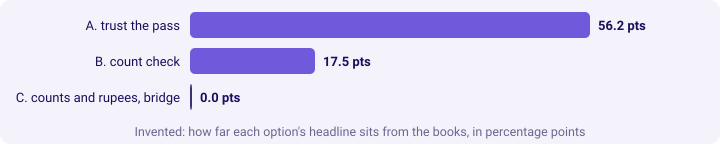

In [6]:
SIZING_HEADERS = ["option", "analyst minutes", "cells", "what it needs", "what it can see",
                  "Q1 to Q2 it lets through", "points off the books"]


def size_options(src, book):
    """Run the hurried pass, apply each check, and fix only what that check can see."""
    books = change(ctl("Q1", book)[0], ctl("Q2", book)[0])
    out = []
    for name, minutes, cells, needs, sees, dedupe, read in [
            ("A. trust the pass", 0, 0, "nothing", "nothing", False, False),
            ("B. count check", 2, 1, "Finance's order counts", "rows beyond Finance's orders", True, False),
            ("C. counts and rupees, bridge", 15, 3, "Finance's rupee totals too",
             "extra rows, and rupees the kept rows lost", True, True)]:
        t = quarter_totals(first_of_each(src) if dedupe else src, text_to_zero=not read)
        sent = change(t["Q1"][0], t["Q2"][0])
        out.append((name, minutes, cells, needs, sees, f"{sent:+.1f}%", round(abs(sent - books), 1)))
    out.append(("D. order-level match", "about 120", 6, "Finance's ledger", "every order that differs, by id",
                "not run: no ledger", "not run"))
    return out


sizing = size_options(rows, control)
kit.table(SIZING_HEADERS, sizing, caption=f"Invented: four ways to check, sized; the books say {truth:+.1f}%")
kit.bars([(s[0], s[6]) for s in sizing[:3]], lit=(2,), fmt=lambda v: f"{v:.1f} pts",
         title="Invented: how far each option's headline sits from the books, in percentage points")

In [7]:
kit.check("only C, of the options that can run here, lands on the books",
          sizing[2][6] == 0 and all(s[6] > 1 for s in sizing[:2]))
kit.check("the count check moves the headline and still misses the books",
          sizing[1][5] != sizing[0][5] and sizing[1][6] > 1)

**What happened, and the best-fit call.** C. It costs about fifteen of an analyst's 120 minutes,
needs only the control file that came with the export, and is the one option run here that lands
on the books to the rupee. A lets the invented export's +21.2 percent through, 56.2 points off. B
is where most people who did check stopped, and it still leaves the headline 17.5 points off. D
would name every order that differs, which C cannot, at the cost of a request to Finance and most
of the afternoon.

**What would change the call.** No control total at all: C then has nothing to land on, and D, or
a second export pulled from the source system for the same quarters, becomes the check. A bridge
that will not close: C has found a gap it cannot explain, and D is how you find which orders make
it.

**Your turn, on this morning's file.** Size the same four options on the lab export. Type this
line into the empty cell below and run it:

```python
kit.table(SIZING_HEADERS, size_options(lab, lab_book), caption="The four checks on this morning's file")
```

Where did your own lab run sit in this table?

## 3. What does the count check fix, and what does it leave behind?

Option B keeps one row per order id and compares the orders in each quarter with Finance's order
counts. The rows it sets aside go to a rejected list, so rows read equal rows kept plus rows
rejected.

**Predict before you run.** After B's fix, what does the invented export's headline say?

- a) Q2 up 21.2 percent, unchanged.
- b) Q2 down 35.0 percent, the books.
- c) Q2 down 17.5 percent.
- d) The check cannot run without the order-level ledger.

In [8]:
once = first_of_each(rows)
counted = quarter_totals(once, text_to_zero=True)
c_change = change(counted["Q1"][0], counted["Q2"][0])
seen, rejected = set(), []
for r in rows:
    if r["order_id"] in seen:
        rejected.append(r)
    seen.add(r["order_id"])
kit.table(["quarter", "orders kept", "Finance's orders", "rupees kept", "Finance's rupees"],
          [(q, counted[q][1], ctl(q)[1], kit.rupees(counted[q][0]), kit.rupees(ctl(q)[0])) for q in QUARTERS],
          caption=f"Invented, after the count check: {len(rows)} rows read, {len(once)} kept, {len(rejected)} set aside")
kit.check("input equals kept plus rejected, each list built on its own", len(rows) == len(once) + len(rejected))
kit.check("the order counts now land on Finance's in both quarters", all(counted[q][1] == ctl(q)[1] for q in QUARTERS))
kit.check("the rupees still miss Finance's control totals", any(counted[q][0] != ctl(q)[0] for q in QUARTERS),
          f"Q1 to Q2 after the count check {c_change:+.1f}%")

quarter,orders kept,Finance's orders,rupees kept,Finance's rupees
Q1,83,83,"Rs 31,50,000","Rs 40,00,000"
Q2,84,84,"Rs 26,00,000","Rs 26,00,000"


**What happened.** The answer is c. Every order count lands, and the invented headline moves from
+21.2 to -17.5 percent: the right direction at half the size. A count check proves the rows are
there and says nothing about whether each row's value survived the conversion; Q1 still sums to Rs
31,50,000 against Finance's Rs 40,00,000. That gap is chapter 2's question.

**Your turn, on this morning's file.** Run the count check on the lab export. Type these lines into
the empty cell below and run it:

```python
lab_once = first_of_each(lab)
lab_counted = quarter_totals(lab_once, text_to_zero=True)
kit.table(["quarter", "orders kept", "Finance's orders", "rupees kept", "Finance's rupees"],
          [(q, lab_counted[q][1], ctl(q, lab_book)[1], kit.rupees(lab_counted[q][0]),
            kit.rupees(ctl(q, lab_book)[0])) for q in QUARTERS],
          caption=f"This morning's file after the count check: {len(lab)} rows read, {len(lab_once)} kept")
```

Do the counts land, and do the rupees?

## 4. Which two moves walk the hurried sum to Finance's total?

Option C adds the rupee comparison and draws the walk from what the hurried run summed to what
Finance booked, one move per decision in the log: the rows Finance does not hold come out, and the
value that would not convert is read back in.

**Predict before you run.** On the invented export, which move is the larger?

- a) The rows Finance does not hold.
- b) The value that would not convert.
- c) They are equal.
- d) Neither; the walk closes with no moves.

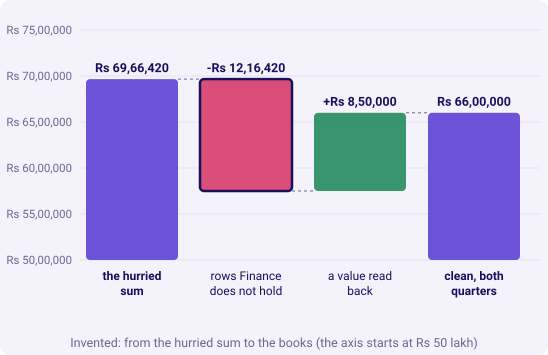

In [9]:
def bridge_moves(src):
    """The hurried sum of both quarters, the rupees the count check removed, and the rupees read back."""
    as_read = sum(t for t, _ in quarter_totals(src, text_to_zero=True).values())
    counted_sum = sum(t for t, _ in quarter_totals(first_of_each(src), text_to_zero=True).values())
    clean_sum = sum(t for t, _ in quarter_totals(first_of_each(src), text_to_zero=False).values())
    return as_read, counted_sum - as_read, clean_sum - counted_sum


as_read, extra_rows, text_back = bridge_moves(rows)
kit.bridge(("the hurried sum", as_read), [("rows Finance does not hold", extra_rows), ("a value read back", text_back)],
           end_label="clean, both quarters", lit=[0], lo=5_000_000,
           title="Invented: from the hurried sum to the books (the axis starts at Rs 50 lakh)")
clean = quarter_totals(once, text_to_zero=False)
kit.check("the bridge lands on Finance's two quarters together",
          as_read + extra_rows + text_back == ctl("Q1")[0] + ctl("Q2")[0], kit.rupees(ctl("Q1")[0] + ctl("Q2")[0]))
kit.check("both quarters land, orders and rupees", all(clean[q] == ctl(q) for q in QUARTERS))

**What happened.** The answer is a. On the invented export the rows Finance does not hold carry Rs
12,16,420 and the value read back carries Rs 8,50,000, and the walk from Rs 69,66,420 lands on Rs
66,00,000, Finance's two quarters together. Both moves had to be found before it landed.

**The fix, and what it changes.** With both quarters on the books the invented headline is a fall
of 35.0 percent, from Rs 40,00,000 to Rs 26,00,000. The note changes sign, so the decision changes
with it: Monday's review now has a fall of Rs 14,00,000 to explain, and chapter 3 finds where it
sits.

**Your turn, on this morning's file.** Draw this morning's bridge and read which move is the
larger there. Type these lines into the empty cell below and run it:

```python
lab_read, lab_extra, lab_back = bridge_moves(lab)
kit.bridge(("the hurried sum", lab_read), [("rows Finance does not hold", lab_extra),
                                           ("a value read back", lab_back)],
           end_label="clean, both quarters", lit=[0], lo=9_000_000,
           title="This morning's file: from the hurried sum to the books (the axis starts at Rs 90 lakh)")
```

run,Q1 to Q2
the hurried run,+21.2%
count check only,-17.5%
counts and rupees,-35.0%


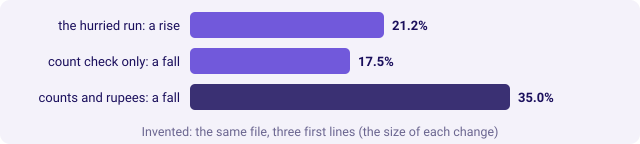

In [10]:
variants = [("the hurried run", hurried), ("count check only", counted), ("counts and rupees", clean)]
heads = [(n, change(t["Q1"][0], t["Q2"][0])) for n, t in variants]
kit.table(["run", "Q1 to Q2"], [(n, f"{h:+.1f}%") for n, h in heads], caption="Invented: one export, three headlines")
kit.bars([(f"{n}: {'a rise' if h > 0 else 'a fall'}", round(abs(h), 1)) for n, h in heads], lit=(2,),
         fmt=lambda v: f"{v:.1f}%", width=640, title="Invented: the same file, three first lines (the size of each change)")

## 5. Does a sum of the decisions themselves land on the same two moves?

The bridge's two moves were found by subtracting one total from another. The second route builds
the evidence on its own: every row set aside as a repeat of an order already kept, summed from the
set-aside list, and every value read back from text, summed from the decisions log. Each sum must
equal its move in the bridge. The first route is arithmetic on totals and this one sums the
decisions themselves, so a row set aside without its log line, or a value set to zero where it
should have been read, makes the two disagree.

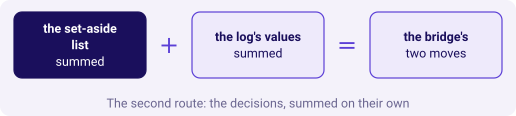

In [11]:
def decisions(src):
    """The rows set aside as repeats, and one log line per value read back from text."""
    set_aside, log, kept_ids = [], [], set()
    for r in src:
        if r["order_id"] in kept_ids:
            set_aside.append(r)
            continue
        kept_ids.add(r["order_id"])
        if not r["amount"].isdigit():
            log.append({"order_id": r["order_id"], "decision": "convert and flag", "read_as": read_value(r["amount"])})
    return set_aside, log


set_aside, log = decisions(rows)
set_aside_rupees = sum(read_value(r["amount"]) for r in set_aside)
read_back = sum(e["read_as"] for e in log)
kit.equation(["the set-aside list\nsummed", "+", "the log's values\nsummed", "=", "the bridge's\ntwo moves"],
             title="The second route: the decisions, summed on their own")
kit.check("the rows set aside add up to the rupees the bridge took out", set_aside_rupees == -extra_rows,
          f"{len(set_aside)} rows, {kit.rupees(set_aside_rupees)}")
kit.check("the values in the log add up to the rupees the bridge read back", read_back == text_back,
          f"{len(log)} line, {kit.rupees(read_back)}")

**What happened.** Both sums land: on the invented export the 8 rows set aside come to Rs
12,16,420 and the one log line reads back Rs 8,50,000, each equal to its move in the bridge.

**When to switch routes.** Show Finance the forward bridge, because it starts from their export.
Run this second route before you send it: it proves every rupee the bridge moved is a row in the
set-aside list or a value in the log, each summed on its own. It cannot tell you whether each
decision was right, whether a row set aside really repeats an order or a value was read correctly;
the order-level match is what answers that.

**Your turn, on this morning's file.** The bridge says how many rupees Finance does not hold. It
does not say which rows they are, and Anand will ask. Type these lines into the empty cell below
and run it:

```python
lab_set_aside, lab_log = decisions(lab)
kit.check("this morning's set-aside rows add up to the bridge's first move",
          sum(read_value(r["amount"]) for r in lab_set_aside) == -lab_extra)
kit.check("this morning's log adds up to the bridge's second move", sum(e["read_as"] for e in lab_log) == lab_back)
kit.table(list(lab[0]), [list(r.values()) for r in lab_set_aside], caption="Rows Finance does not hold")
```

Read the dates and the segments: what do the rows have in common, and what would you tell the
person who owns the export?

## Depth: can the same repeated rows move a branch of the tree as well?

Rows Finance does not hold inflate a total, and when they sit in one segment they can move a branch
too: extra rows for the same customers read as customers ordering more often. The cell below runs
the tree's two lower branches for each consumer segment of the invented export, on the hurried rows
and on one row per order.

In [12]:
def branch(src, q, seg):
    """Orders per customer and revenue per order for one segment and quarter, on the rows that convert."""
    rs = [r for r in src if r["quarter"] == q and r["segment"] == seg and r["amount"].isdigit()]
    return len(rs) / len({r["customer_id"] for r in rs}), sum(int(r["amount"]) for r in rs) / len(rs)


out = []
for seg in SEGS[:3]:
    (fh1, _), (fh2, _) = branch(rows, "Q1", seg), branch(rows, "Q2", seg)
    (fc1, bc1), (fc2, bc2) = branch(once, "Q1", seg), branch(once, "Q2", seg)
    out.append((seg, f"{fh1:.2f} to {fh2:.2f}", f"{fc1:.2f} to {fc2:.2f}", f"{change(bc1, bc2):+.1f}%"))
kit.table(["segment", "orders per customer, hurried rows", "orders per customer, one row per order",
           "revenue per order, one row per order"], out, caption="Invented: the same rows, two readings of a branch")
kit.check("the repeated rows make one segment's customers look as if they order more often",
          any(o[1] != o[2] for o in out))

segment,"orders per customer, hurried rows","orders per customer, one row per order","revenue per order, one row per order"
Retail-Core,1.46 to 1.50,1.46 to 1.50,-0.6%
Retail-Plus,2.00 to 2.44,2.00 to 2.00,-15.0%
Student,1.00 to 1.40,1.00 to 1.40,-2.2%


**What happened.** On the invented export the repeated batch sits in Retail-Plus: its members seem to
order 2.44 times each in Q2 against 2.00 in Q1 on the hurried rows, a fifth more often, while one
row per order shows frequency flat at 2.00 and revenue per order down 15.0 percent. A note built on
the hurried rows would have named a frequency rise that never happened and missed the basket fall.

**Your turn, on this morning's file.** Run the same comparison on the lab export. Type these lines
into the empty cell below and run it:

```python
for seg in SEGS[:3]:
    (fh1, _), (fh2, _) = branch(lab, "Q1", seg), branch(lab, "Q2", seg)
    (fc1, bc1), (fc2, bc2) = branch(lab_once, "Q1", seg), branch(lab_once, "Q2", seg)
    print(f"{seg}: orders per customer {fh1:.2f} to {fh2:.2f} hurried, {fc1:.2f} to {fc2:.2f} one row "
          f"per order; revenue per order {change(bc1, bc2):+.1f}%")
```

Where do this morning's repeated rows sit, and which branch would a note built on the hurried rows
have named?

> **Kavya's review.** A number that has not been reconciled can point the wrong way, and on this
> morning's file it did for most of the room. Put the two checks in a cell before you compute the
> first number you plan to send, so the clock cannot remove them.

### How would you answer this in an interview?

**[S] Walk me through how you clean and check a dataset you have never seen.** "I profile every
field first: present, convertible and distinct counts, and each count that is not what the field
should hold is a finding. I clean with a log, one row per decision with its reason, and I keep what
I reject. Then I reconcile before I analyse: rows read equal rows kept plus rows rejected, and each
period's value lands on a total from outside the file, Finance's if there is one. On a two-quarter
export in training, the count check alone moved my headline from +21.2 to -17.5 percent, and only
the rupee check reached the books' -35.0, so I never stop at counts."

**[F] You have two hours and a raw export; what do you do first, and what do you skip?** "Profile
first, twenty minutes. I never skip the reconciliation, because it is the step that can flip the
sign of the finding and it costs fifteen minutes. I skip anything that does not change today's
answer: a second chart, a test on every segment, polishing. If there is no control total, I say so
in the caveat and ask for one before the number leaves the room."

**The design question: which check, and what would make you switch?** "Counts and rupees against a
control total, with a bridge, because it catches both kinds of error for fifteen minutes and needs
only what comes with the export. I switch to an order-level match against the ledger when the bridge
will not close or when there is no control total, and I say it will cost the afternoon."

### What do you check against when there is no control total?

Three stand-ins, in the order a careful analyst tries them: the same quarters in a second export
pulled from the source system on another day; the payment gateway's settlement totals for the
quarter, which count collected money and so need their own bridge to booked money; last quarter's
audited figure for the quarter that overlaps. Each is weaker than Finance's number, and the note
says which one was used.

## So, do the two quarters in your note match Finance's books?

Only once both checks have run. On the invented export:

1. A pass that skips the reconciliation sends Q2 up 21.2 percent, where the books say down 35.0.
2. Counts and rupees with a bridge (C) is the best fit: fifteen minutes, the only option run here
   that lands to the rupee, and D takes over when there is no control total or the bridge will not
   close.
3. The count check lands every order and leaves the headline at -17.5 percent, half its size.
4. Rs 12,16,420 of rows Finance does not hold come out and Rs 8,50,000 is read back, and the walk
   lands on Rs 66,00,000.
5. The set-aside list and the log, each summed on its own, equal the two moves.

Your your-turn cells put this morning's file through the same five steps. Chapter 2 asks the
question the count check left open: when every count lands and nothing was rejected, what else can
a pass have lost?

In [13]:
kit.check_summary()
print("Next, chapter 2: every count reconciles and nothing was rejected, so is the pass finished?")

Next, chapter 2: every count reconciles and nothing was rejected, so is the pass finished?
